In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def plot_kappa_17regions(csv_path, out_png):
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    # ---------- 1. 读 CSV ----------
    df = pd.read_csv(csv_path)

    # 排序（保证时间顺序）
    df = df.sort_values(["region", "mode", "year"])

    # region 顺序：GLOBAL / WLD 放最后
    regions = sorted(
        [r for r in df["region"].unique() if r not in ["GLOBAL", "WLD"]]
    )
    if "GLOBAL" in df["region"].values:
        regions.append("GLOBAL")
    elif "WLD" in df["region"].values:
        regions.append("WLD")

    regions_plot = regions
    n = len(regions_plot)

    # ---------- 2. 子图布局 ----------
    ncols = 5
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(16, 12),
        sharex=True,
        sharey=True
    )
    axes = axes.flatten()

    # ---------- 3. 逐地域画图 ----------
    for i, reg in enumerate(regions_plot):
        ax = axes[i]
        d_reg = df[df["region"] == reg]

        # Basin
        d_basin = d_reg[d_reg["mode"] == "basin"]
        ax.plot(
            d_basin["year"],
            d_basin["kappa"],
            color="blue",
            label="Basin"
        )

        # Region
        d_region = d_reg[d_reg["mode"] == "region"]
        ax.plot(
            d_region["year"],
            d_region["kappa"],
            color="red",
            label="Region"
        )

        ax.set_title(reg)
        ax.set_ylim(0, 1.2)
        ax.grid(alpha=0.3)

        # 行列位置
        row = i // ncols
        col = i % ncols

        # y 轴：只在最左列显示
        if col == 0:
            ax.set_ylabel("Kappa", fontsize=13)
            ax.tick_params(axis="y", labelleft=True)
        else:
            ax.tick_params(axis="y", labelleft=False)

        # x 轴：只在最后一行显示
        if row == nrows - 1:
            ax.set_xlabel("Year", fontsize=13)
            ax.tick_params(axis="x", labelbottom=True)
        else:
            ax.tick_params(axis="x", labelbottom=False)

    # ---------- 4. 公共 legend ----------
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        loc="lower right",
        ncol=2,
        fontsize=22
    )

    # ---------- 5. 删除多余子图 ----------
    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(out_png, dpi=600, bbox_inches="tight")
    plt.show()


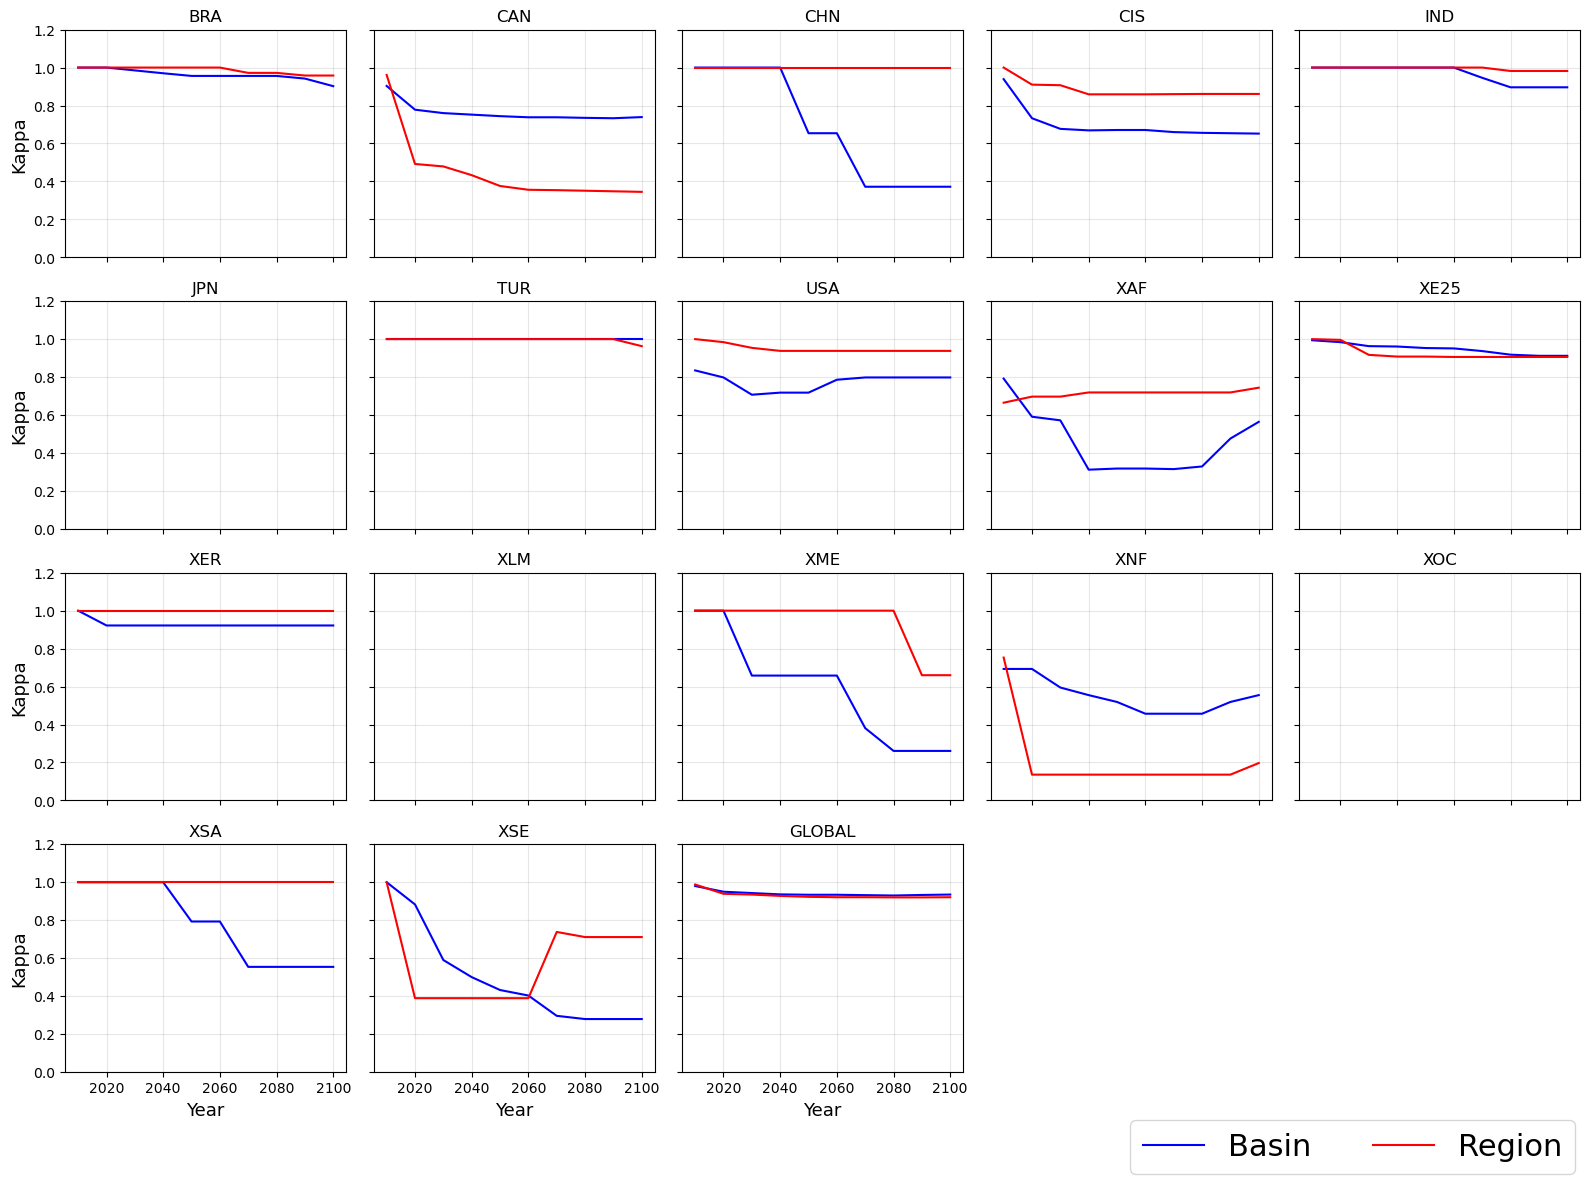

In [12]:
plot_kappa_17regions(
    csv_path="../../CSV/kappa/kappa_agri_consistent_vs2005_.csv",
    out_png="../../plot/kappa/17+1regions_kappa_compare_to_2005_consistent.png"
)